# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [44]:
# complete imports if needed for your solution
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GINConv, GATConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.loader import DataLoader
from rdkit import Chem

Load the data from Session 11

In [2]:
df = pd.read_csv(os.path.join("..", "..", "lectures", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])
df = df.loc[df.SMILES != 'C'] # remove the one compound containing only a single atom
df.head()

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.


In [9]:
X = df.drop(["SMILES", "LogP"], axis=1)
y = df["LogP"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

R2 for training set: 0.9869239722927238
R2 for test set: 0.9116947549166072
RMSE for training set: 0.21033652727599736
RMSE for test set: 0.5651480407411424


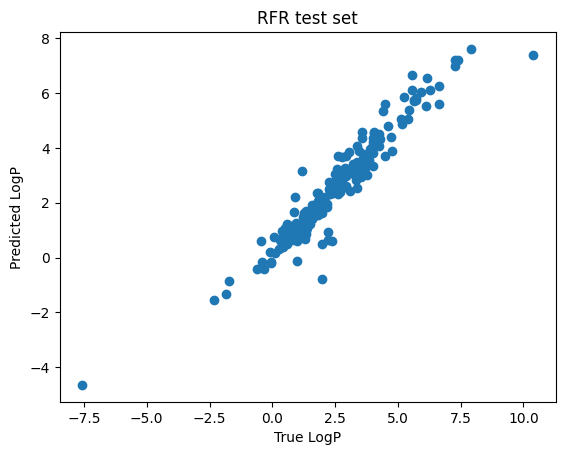

In [45]:
RFR = RandomForestRegressor(n_estimators=50, random_state=42)
RFR.fit(X_train, y_train)
y_test_pred_RFR = RFR.predict(X_test)
y_train_pred_RFR = RFR.predict(X_train)

print(f"R2 for training set: {r2_score(y_train, y_train_pred_RFR)}")
print(f"R2 for test set: {r2_score(y_test, y_test_pred_RFR)}")
print(f"RMSE for training set: {root_mean_squared_error(y_train, y_train_pred_RFR)}")
print(f"RMSE for test set: {root_mean_squared_error(y_test, y_test_pred_RFR)}")

plt.scatter(y_test, y_test_pred_RFR)
plt.xlabel("True LogP")
plt.ylabel("Predicted LogP")
plt.title("RFR test set")
plt.show()

### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

In [19]:
def atom_features(atom): # Create a tensor for atom features, length = 5
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond): # Create a tensor for bond features, length = 6
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

In [23]:
def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles) # Create a RDKit mol object from the smiles

    # Calculate atom features for all atoms in the molecule
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []
    
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Represent molecule as an undirected graph --> add both directions
        edge_index.append([i, j]) # left to right
        edge_index.append([j, i]) # right to left

        bf = bond_features(bond) # calculate bond features 
        edge_attr.append(bf)
        edge_attr.append(bf) # add two times, once for forward and once for backwards edge

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
    edge_attr  = torch.stack(edge_attr, dim=0)

    # Target property: logP
    y = torch.tensor([y], dtype=torch.float)
    
    # x: atom stack, y: logP
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [24]:
graphs = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df.iterrows()]

In [85]:
class GCNModel(torch.nn.Module):
    def __init__(self, dim_h=64): # dim_h: Size of hidden layer
        super().__init__()
        self.conv1 = GCNConv(5, dim_h) # first convolution layer: in_channels: 5, number of atom features
        self.conv2 = GCNConv(dim_h, dim_h) # second convolution layer
        self.lin = torch.nn.Linear(dim_h, 1) # output layer
        
    # Define how the data flows through the layers
    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))  # input layer: convolution + activation function (ReLu)
        x = torch.relu(self.conv2(x, edge_index))  # hidden layer: convolution + activation function (ReLu)
        x = global_mean_pool(x, batch)             # pooling function
        return self.lin(x).squeeze(-1)

In [86]:
class GINModel(torch.nn.Module):
    def __init__(self, dim_h=64):
        super().__init__()

        nn1 = torch.nn.Sequential(
            torch.nn.Linear(5, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(dim_h, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch) # try: global_add_pool(x, batch)
        return self.lin(x).squeeze(-1)

In [87]:
class GATModel(torch.nn.Module):
    def __init__(self, dim_h=64, heads=4):
        super().__init__()

        # Input layer
        self.conv1 = GATConv(
            in_channels=5,        # your atom feature size
            out_channels=dim_h,  # hidden dimension per head
            heads=heads,
            dropout=0.1,
            concat=True           # concatenates heads --> output = hidden * heads
        )

        # Second layer
        self.conv2 = GATConv(
            in_channels=dim_h * heads,
            out_channels=dim_h,
            heads=1,
            dropout=0.1,
            concat=False          # final output shape = (hidden,)
        )

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)


In [88]:
def evaluate(model, loader):
    model.eval()
    criterion = torch.nn.MSELoss()
    losses = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            losses.append(loss.item())

    return sum(losses) / len(losses)

In [89]:
def train(model, train_loader, val_loader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # lr: learning rate
    criterion = torch.nn.MSELoss() # loss function

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad() # Reset gradients
            pred = model(batch.x, batch.edge_index, batch.batch) # predict on batch
            loss = criterion(pred, batch.y) # define criterion
            loss.backward() # computes the gradient of the loss
            optimizer.step() # Perform an optimization step
            train_losses.append(loss.item())

        val_loss = evaluate(model, val_loader) # evaluate re-trained model on validation data

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss = {sum(train_losses)/len(train_losses):.4f} | " # average train loss
              f"Val Loss = {val_loss:.4f}") 


def test(model, test_loader):
    test_loss = evaluate(model, test_loader)
    print(f"\nTest Loss: {test_loss:.4f}")

In [90]:
def create_splits(graphs, train_ratio=0.8, val_ratio=0.1, seed=42):
    torch.manual_seed(seed)
    graphs = graphs.copy()
    permutation = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in permutation]

    n = len(graphs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train + n_val]
    test_graphs  = graphs[n_train + n_val:]

    return train_graphs, val_graphs, test_graphs

train_graphs, val_graphs, test_graphs = create_splits(graphs)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)

In [91]:
loader = DataLoader(graphs, batch_size=100, shuffle=True)

In [97]:
gcn = GCNModel()
gin = GINModel()
gat = GATModel()

epochs = 100
learning_rate = 0.005

print("\n=== Training GCN ===")
train(gcn, train_loader, val_loader, epochs=epochs, lr=learning_rate)
test(gcn, test_loader)

print("\n=== Training GIN ===")
train(gin, train_loader, val_loader, epochs=epochs, lr=learning_rate)
test(gin, test_loader)

print("\n=== Training GAT ===")
train(gat, train_loader, val_loader, epochs=epochs, lr=learning_rate)
test(gat, test_loader)


=== Training GCN ===
Epoch 01 | Train Loss = 3.6550 | Val Loss = 5.0766
Epoch 02 | Train Loss = 3.2965 | Val Loss = 4.7857
Epoch 03 | Train Loss = 3.3676 | Val Loss = 4.6597
Epoch 04 | Train Loss = 3.2798 | Val Loss = 4.5631
Epoch 05 | Train Loss = 3.0657 | Val Loss = 4.7166
Epoch 06 | Train Loss = 3.0407 | Val Loss = 4.4165
Epoch 07 | Train Loss = 2.9342 | Val Loss = 4.2932
Epoch 08 | Train Loss = 3.0690 | Val Loss = 4.3404
Epoch 09 | Train Loss = 2.7764 | Val Loss = 4.4188
Epoch 10 | Train Loss = 2.7377 | Val Loss = 3.9307
Epoch 11 | Train Loss = 2.6732 | Val Loss = 4.1493
Epoch 12 | Train Loss = 2.6074 | Val Loss = 3.5538
Epoch 13 | Train Loss = 2.7509 | Val Loss = 3.4211
Epoch 14 | Train Loss = 2.6286 | Val Loss = 3.2167
Epoch 15 | Train Loss = 2.3620 | Val Loss = 3.0965
Epoch 16 | Train Loss = 2.2796 | Val Loss = 2.8566
Epoch 17 | Train Loss = 2.1994 | Val Loss = 2.9845
Epoch 18 | Train Loss = 2.1464 | Val Loss = 2.5697
Epoch 19 | Train Loss = 2.0688 | Val Loss = 2.5639
Epoch 20 

In [98]:
def parity_plot(model, test_loader, title="Parity Plot (Test Set)"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch)

            # Ensure correct shapes
            pred = pred.view(-1).cpu()
            y = batch.y.view(-1).cpu()

            preds.append(pred)
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    # Parity plot
    plt.figure(figsize=(5,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()],
             [trues.min(), trues.max()],
             color='red', linestyle='--', linewidth=2)

    plt.xlabel("True logP")
    plt.ylabel("Predicted logP")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print(f"R2 score: {r2_score(trues, preds)}")


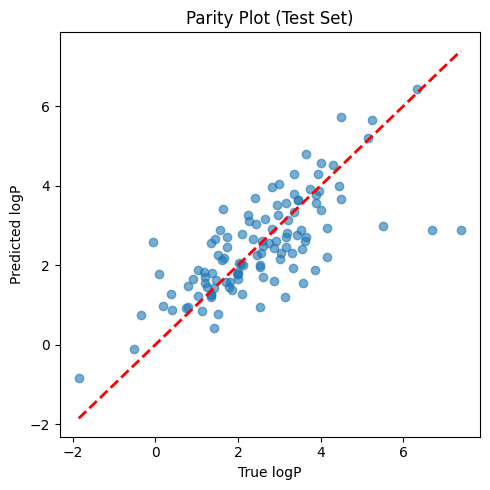

R2 score: 0.517614483833313


In [99]:
parity_plot(gcn, test_loader)

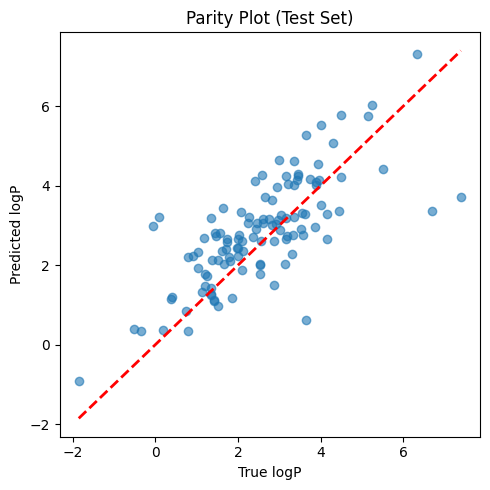

R2 score: 0.46671873331069946


In [100]:
parity_plot(gin, test_loader)

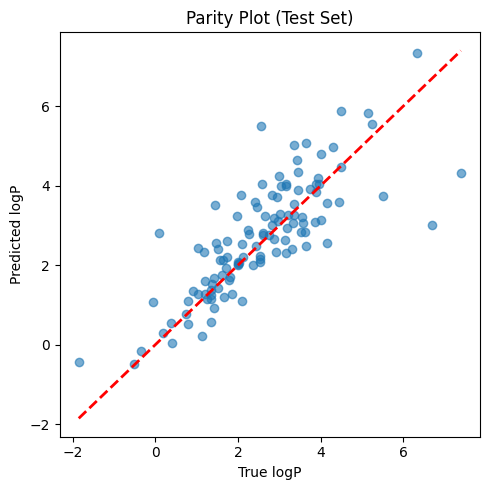

R2 score: 0.5890129804611206


In [101]:
parity_plot(gat, test_loader)

### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?
- The supervised model performed significantly better on the test set. This is because it is significantly easier to predict the LogP from the descriptors with supervised learning rather than the graphs which learns the structural properties which are not as related to the LogP.
2) What did you try to improve model performance of your GNN? What did work, what did not work?
- I tried increasing or decreasing the number of epochs and learning rate. these helped a little bit, but not a lot. it was also very hard to compare as even if i changed nothing, the results would be vastly different. I also tried using the three different models (GCN, GIN and GAT) there was a significant difference between these, but the results were still not nearly as good as that of the RFR.
3) Which challenges did you face in the process of building the models?
- To be fully honest, the biggest challenge for me was the coding for the GNN models, I ended up just having to copy the code given in session 14, but I still do not fully understand all of the code and would not be able to reproduce it on my own.
4) Which of your two models would you recommend to a chemist for predicting logP, and why?
- easily the RFR because of multiple reasons, first of all, the results are significantly better, the code is way simpler and easier to understand (important for a chemist without any background in data analysis/ML) and it takes less time to run it.